In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

In [3]:
image = cv2.imread("../images/berry.png", 0)
# plt.imshow(image, cmap="gray")
# plt.axis("off")
# plt.show()

In [4]:
def compute_histogram(image):
    histogram = np.zeros(256, np.int32)
    flattened_image = image.flatten()
    for pixel in flattened_image:
        histogram[pixel] += 1

    return histogram

In [5]:
def compute_histogram_numpy(image):
    flattened_image = image.flatten()
    histogram = np.bincount(flattened_image, minlength=256).astype(np.int32)

    return histogram

In [6]:
colors = np.array(
    [[1, 1, 1], [1, 0, 0], [0, 1, 0], [0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 0]]
)

color_name = ["white", "red", "green", "blue", "cyan", "magenta", "yellow"]

In [7]:
shades = np.zeros((7, 3, 3))

for i in range(7):
    for j in range(3):
        shades[i, j] = colors[i] * j / 2

shades

array([[[0. , 0. , 0. ],
        [0.5, 0.5, 0.5],
        [1. , 1. , 1. ]],

       [[0. , 0. , 0. ],
        [0.5, 0. , 0. ],
        [1. , 0. , 0. ]],

       [[0. , 0. , 0. ],
        [0. , 0.5, 0. ],
        [0. , 1. , 0. ]],

       [[0. , 0. , 0. ],
        [0. , 0. , 0.5],
        [0. , 0. , 1. ]],

       [[0. , 0. , 0. ],
        [0. , 0.5, 0.5],
        [0. , 1. , 1. ]],

       [[0. , 0. , 0. ],
        [0.5, 0. , 0.5],
        [1. , 0. , 1. ]],

       [[0. , 0. , 0. ],
        [0.5, 0.5, 0. ],
        [1. , 1. , 0. ]]])

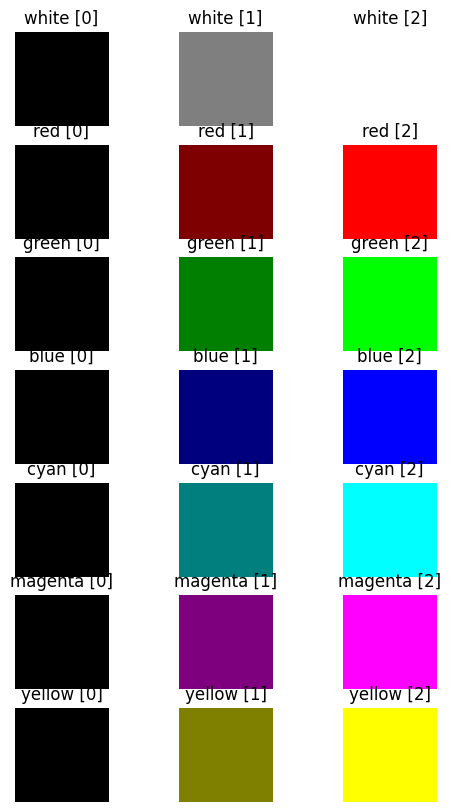

In [8]:
fig, ax = plt.subplots(7, 3, figsize=(6, 10))

for i in range(7):
    for j in range(3):
        ax[i, j].imshow(np.broadcast_to(shades[i, j], (50, 50, 3)))
        ax[i, j].set_title(f"{color_name[i]} [{j}]")
        ax[i, j].axis("off")

plt.show()

In [9]:
def custom_filter2d(image, kernel, mode="same"):
    image = np.float32(image)
    kernel = np.float32(kernel)

    kh, kw = kernel.shape

    kernel = np.flipud(np.fliplr(kernel))

    if mode == "same":
        padded_image = np.pad(
            image, ((kh // 2, kh // 2), (kw // 2, kw // 2)), mode="reflect"
        )

    elif mode == "valid":
        padded_image = image

    ph, pw = padded_image.shape
    oh = ph - kh + 1
    ow = pw - kw + 1
    output = np.zeros((oh, ow), dtype=np.float32)

    for i in range(oh):
        for j in range(ow):
            region = padded_image[i : i + kh, j : j + kw]
            output[i, j] = np.sum(region * kernel)

    return output

In [10]:
avg_kernel = np.ones((3, 3), dtype=np.float32) / 9

In [11]:
built_in_filter = cv2.filter2D(image, -1, avg_kernel)
custom_filter = custom_filter2d(image, avg_kernel)

In [12]:
difference = built_in_filter - custom_filter

center = difference[2:-2, 2:-2]
print("Max error (center only):", np.max(np.abs(center)))

Max error (center only): 0.444458


In [13]:
print("All close:", np.allclose(built_in_filter, custom_filter, atol=0.1))
print("Max error:", np.max(np.abs(built_in_filter - custom_filter)))

All close: False
Max error: 0.444458


In [14]:
def custom_heq(image):
    hist = np.zeros(256)

    for i in image.flatten():
        hist[i] += 1

    hist = hist / image.size

    cdf = np.cumsum(hist)

    new_values = np.round(cdf * 255).astype(np.uint8)

    return new_values[image]

In [15]:
custom_heq_res = custom_heq(image)
cv2_heq_res = cv2.equalizeHist(image)

In [16]:
np.allclose(custom_heq_res, cv2_heq_res)

True

In [17]:
def get_bit_planes(image):
    bit_planes = []

    for i in range(8):
        plane = (image >> i) & 1
        plane = plane * 255
        bit_planes.append(plane)

    return bit_planes

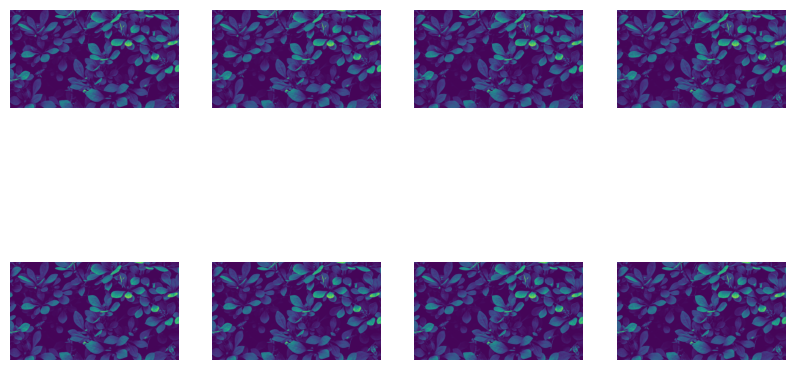

In [18]:
fig, ax = plt.subplots(2, 4, figsize=(10, 6))

ax = ax.flatten()

for i in range(8):
    ax[i].imshow(image)
    ax[i].axis("off")

plt.show()

In [19]:
np.bincount([1, 2, 3, 3, 2, 2, 2], minlength=3)

array([0, 1, 4, 2])

In [20]:
cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))

array([[0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0]], dtype=uint8)

In [21]:
cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

array([[0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0]], dtype=uint8)

In [22]:
def adjust_contrast(img, alpha=1.5):
    img = np.float32(img)
    img = img * alpha
    return np.uint8(np.clip(img, 0, 255))


low_contrast = adjust_contrast(image, alpha=0.5)
normal_contrast = image.copy()
high_contrast = adjust_contrast(image, alpha=1.8)

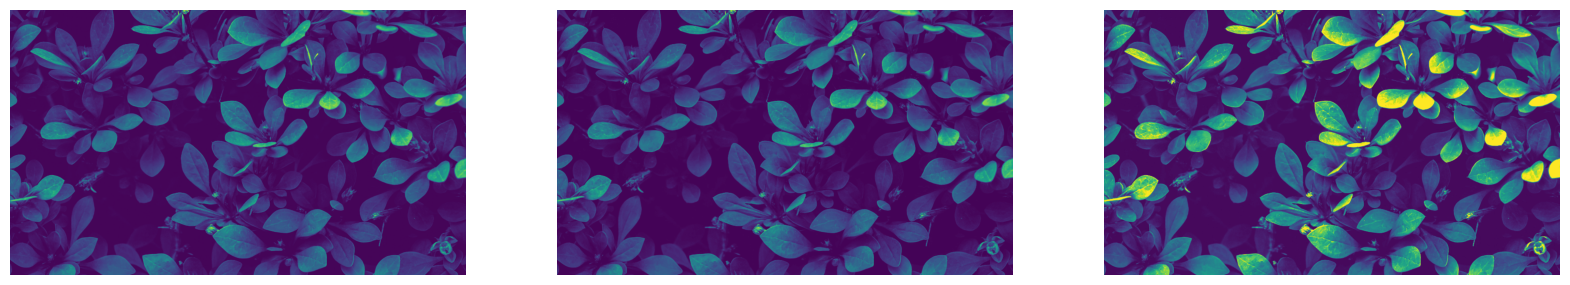

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(normal_contrast)
ax[1].imshow(low_contrast)
ax[2].imshow(high_contrast)
for a in ax:
    a.axis("off")
    
plt.show()

In [24]:
def compute_fft(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(1 + np.abs(fshift))
    return fshift, magnitude

In [25]:
f_low, mag_low = compute_fft(low_contrast)
f_norm, mag_norm = compute_fft(normal_contrast)
f_high, mag_high = compute_fft(high_contrast)

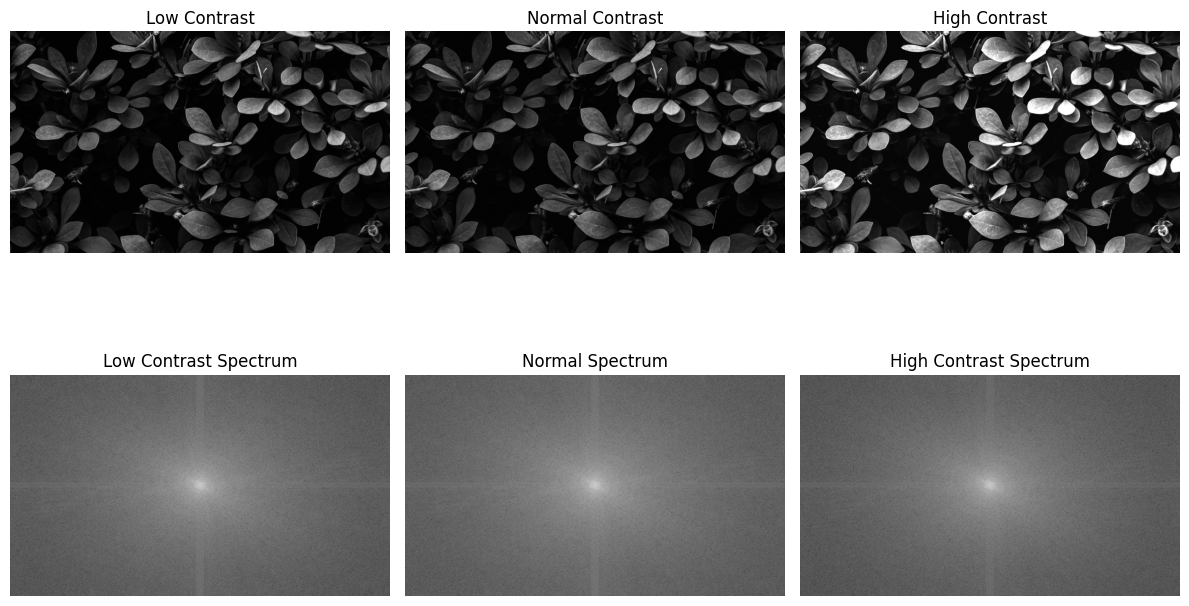

In [26]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low Contrast")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(normal_contrast, cmap='gray')
plt.title("Normal Contrast")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(high_contrast, cmap='gray')
plt.title("High Contrast")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(mag_low, cmap='gray')
plt.title("Low Contrast Spectrum")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(mag_norm, cmap='gray')
plt.title("Normal Spectrum")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(mag_high, cmap='gray')
plt.title("High Contrast Spectrum")
plt.axis("off")

plt.tight_layout()
plt.show()

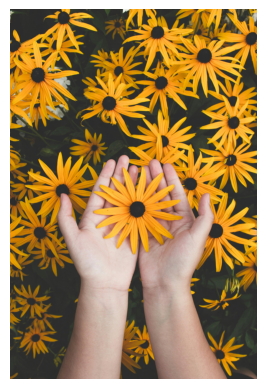

In [29]:
img_bgr = cv2.imread("../images/flower.jpg")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [30]:
def quantize_332(image):
    r = (image[:, :, 0] >> 5) << 5
    g = (image[:, :, 1] >> 5) << 5
    b = (image[:, :, 2] >> 6) << 6

    quantized = np.stack([r, g, b], axis=2)
    return quantized.astype(np.uint8)

In [33]:
img_rgb.shape

(5184, 3456, 3)

In [32]:
quantized = quantize_332(img_rgb)
quantized.shape

(5184, 3456, 3)